In [7]:
from scipy.integrate import solve_ivp
import numpy as np
import torch
from sbalign.training.diffusivity import *
import matplotlib.pyplot as plt

num_k=5
H=0.5

gamma_min = None
gamma_max = 20.0
g_max = 0.7

fbb = FractionalSchrödingerBridge(H=H, K=num_k, gamma_min=gamma_min,gamma_max=gamma_max,g_max=g_max)

omega = fbb.omega 
gamma = fbb.gamma

normalize variance with 1.0
dtype torch.float32
g_max=0.7


In [8]:
x = torch.randn(16,2,3,5)
print(x.unsqueeze(-1).shape)

torch.Size([16, 2, 3, 5, 1])


In [ ]:
def covX(s,t,T, omega, gamma, g):

    # compute cov(X(t),X(T)|Z_s=z) with s<t<=T 
    # expects s,t,T of shape (batch_size,1,1)
    # expects omega,gamma of shape (1,K)

    omega_ij = omega[:,:,None]*omega[:,None,:]
    gamma_i = gamma[:,:,None]
    gamma_j = gamma[:,None,:]
    gamma_ij =  gamma_i + gamma_j

    weight = omega_ij/ gamma_ij

    S = weight * (torch.exp(t*gamma_ij) -torch.exp(s*(gamma_ij))) * torch.exp(-T*gamma_j - t*gamma_i) 
    print('S',S.shape)
    return g**2 * (torch.sum(S,axis=(1,2)))

def covYX(s,t,T, omega, gamma, g):

    # compute cov(Y(t),X(T)|Z_s=z) with s<t<=T 
    # expects s,t,T of shape (batch_size,1,1)
    # expects omega,gamma of shape (1,K)

    gamma_l = gamma[:,:,None] #dim of Y_l
    omega_k = omega[:,None,:]
    gamma_k = gamma[:,None,:]

    weight = omega_k/(gamma_l+gamma_k) #dim of omega_k in X
    S = weight *(torch.exp(t*(gamma_l+gamma_k)) -1)*torch.exp(-t*gamma_l-T*gamma_k)

    return g * torch.sum(S,axis=2)

def covY(s,t,T, gamma):

    # compute cov(Y(t),Y(T)|Z_s=z) with s<t<=T 
    # expects s,t,T of shape (batch_size,1,1)
    # expects omega,gamma of shape (1,K)

    gamma_i = gamma[:,:,None]
    gamma_j = gamma[:,None,:]
    gamma_ij =  gamma_i + gamma_j

    return (torch.exp(-T*gamma_j-t*gamma_i)*(torch.exp(t*gamma_ij)-torch.exp(s*gamma_ij)))/gamma_ij

def covZ(t,T, omega, gamma, g, s=None, eps=1e-4):

    # compute cov(X(t),X(T)|Z_s=z) with s<t<=T 
    # expects s,t,T of shape (batch_size,)
    # expects omega,gamma of shape (1,K)

    t = t[:,None,None] 
    T = T[:,None,None]
    s = torch.zeros_like(t) if s is None else s[:,None,None]

    K = omega.shape[1]
    bs = t.shape[0]
    Sig = torch.zeros(bs, K+1,K+1)
    
    print('s',s.shape)
    print('t',t.shape)
    print('T',T.shape)
    print('omega',omega.shape)
    print('gamma',gamma.shape)
    Sig_xy = covYX(s,t,T, omega, gamma, g)
    print('Sig[:,0,0]',Sig[:,0,0].shape)
    print('covX',covX(s,t,T, omega, gamma, g).shape)
    Sig[:,0,0] = covX(s,t,T, omega, gamma, g)
    Sig[:,1:,0] = Sig_xy
    Sig[:,0,1:] = Sig_xy
    Sig[:,1:,1:] = covY(s,t,T, gamma)

    # I_eps = torch.eye(K, K)[None, :, :] * torch.ones((bs, K, K)) * eps * torch.exp(-2 * gamma * t[:,:,0])[:, :, None]
    # Sig[:,1:,1:] = Sig[:,1:,1:] + I_eps
    # Sig[:,0,0] += eps

    Sig= Sig + torch.eye(K+1, K+1)[None, :, :] * torch.ones((bs, K+1, K+1)) * eps


    #Sig[:,1:,1:] = Sig[:,1:,1:] + torch.eye(K, K)[None, :, :] * torch.ones((bs, K, K)) * eps 

    assert ((torch.diag(Sig[0])>0).all()), f'Found negativ variance: \n {torch.diag(Sig[0])<0}'

    return Sig

# def cond_var(t,T,omega,gamma,g):

#     t = t[:,:,None]
#     T = T[:,:,None]

#     omega_i = omega[:,None,:]
#     omega_j = omega[:,:,None]
#     gamma_i = gamma[:,None,:]
#     gamma_j = gamma[:,:,None]

#     return g * torch.sum((omega_i * omega_j)/(gamma_i+gamma_j) * (1-torch.exp(-(gamma_i+gamma_j)*(T-t))),dim=(1,2))

def sample_pinned(t,T,x0,xT,omega,gamma,g):

    K = omega.shape[1]
    bs = x0.shape[0]

    t = t[:,None,None] 
    T = T[:,None,None]
    s = torch.zeros_like(t)

    mu = torch.zeros(x0.shape+(K+1,))
    mu[:,:,0] = x0

    Sig_zx = torch.zeros(bs,K+1)
    
    Sig_zx[:,0] = covX(s,t,T, omega, gamma, g)
    Sig_zx[:,1:] = covYX(s,t,T, omega, gamma, g)

    var = covX(s,T,T, omega, gamma, g)[:,None,None]
    print('var',var.shape)
    print('mu',mu.shape)
    print('Sig_zx',Sig_zx.shape)
    print('xT',xT.shape)
    print('x0',x0.shape)
    print('Sig(xT-x0)',(Sig_zx[:,None,:] * ((xT-x0)[:,:,None])).shape)
    print('dmu',((1/var) * Sig_zx[:,None,:] * ((xT-x0)[:,:,None])).shape)
    mu_bar = mu + (1/var) * Sig_zx[:,None,:] * ((xT-x0)[:,:,None])
    Sig_bar = covZ(t[:,0,0],t[:,0,0],omega,gamma,g) - (1/var) * (Sig_zx[:,:,None] * Sig_zx[:,None,:])

    assert (Sig_bar.transpose(1, 2) == Sig_bar).all(), f'Covariance is not symmetric'

    noise = sample_from_batch_multivariate_normal(Sig_bar,c=x0.shape[1],h=1,w=1,batch_size=bs, aug_dim=K+1)[:,:,0,0,:]

    return mu_bar + noise

In [10]:
def score_fn(t,T,x,Y,xT,omega, gamma, g):

    mu = meanX(t,T,x,Y,omega,gamma,g)
    var = covX(t,T,T, omega, gamma, g)
    score_x = (xT - mu)/var

    scale = torch.ones(1,1,omega.shape[1]+1)
    scale[:,:,1:] = omega[:,None,:] * zeta(t,T,gamma,g) 

    return scale * score_x[:,:,None]

def zeta(s,t,gamma,g):
    # expects s,t of shape (batch_size,1) and s<=t
    # expects omega and gamma of shape (1,K)
    return g*(torch.exp(-gamma*(t-s))-1)

def meanX(s,t,x,Y,omega,gamma,g):

    # compute E[X(t)|Z_s=z) with s<t - Z_s = (x,Y) 
    # mean of X_T conditioned on Z_t = (x,Y)

    s = s[:,None]
    t = t[:,None]

    weight = omega * zeta(s,t,gamma,g) # of shape (batch_size,K)
    y_part = (torch.sum(weight[:,None,:]*Y, dim=-1)) # assumes an Y of dimension (batch_size,D,K)

    return x + y_part

def meanY(s,t,gamma):

    # compute E[Y(t)|Z_s=z) with s<t 
    # mean of X_T conditioned on Z_t = (x,Y)

    s = s[:,None]
    t = t[:,None]

    return torch.exp(-gamma*(t-s))[:,None,:] * Y

def meanZ(s,t,x,Y,omega,gamma,g):
    mean_x = meanX(s,t,x,Y,omega,gamma,g)
    mean_y = meanY(s,t,gamma)
    print('mean_x',mean_x.unsqueeze(-1).shape)
    print('mean_y',mean_y.shape)
    return torch.cat([mean_x.unsqueeze(-1),mean_y],dim=-1)

In [11]:
def mu(t):
    return torch.zeros_like(t)

def g(t):
    return torch.tensor(g_max)

def numpy_compute_YiYj(t, gamma):
    gamma_i, gamma_j = (
        gamma[0, :, None].cpu().numpy(),
        gamma[0, None, :].cpu().numpy(),
    )
    return (1 - np.exp(-(gamma_i + gamma_j) * t.cpu().numpy())) / (
        gamma_i + gamma_j
    )

def func(t, S, num_k=5):
    t = torch.as_tensor(t)
    A = np.zeros((num_k + 1, num_k + 1))
    A[0, 0] = 2 * mu(t).cpu().numpy()
    A[0, 1:] = -2 * (g(t) * omega[0] * gamma[0]).cpu().numpy()
    A[1:, 1:] = np.diag((mu(t) - gamma[0]).cpu().numpy())
    b = np.zeros(num_k + 1)
    b[0] = (omega[0].cpu().numpy().sum() * g(t).cpu().numpy()) ** 2
    b[1:] = g(t).cpu().numpy() * (
        omega[0].cpu().numpy().sum()
        - numpy_compute_YiYj(t,gamma) @ (omega[0] * gamma[0]).cpu().numpy()
    )

    return A @ S + b

def get_result(t, num_k, gamma):
    S_0 = np.zeros(num_k + 1)
    result = solve_ivp(func, (0., 1.), S_0, dense_output=True)
    S = result.sol(t)
    cov = np.zeros((num_k + 1, num_k + 1))
    cov[0, :] = S
    cov[:, 0] = S
    cov[1:, 1:] = numpy_compute_YiYj(torch.tensor(t),gamma)
    return cov

s torch.Size([1000, 1, 1])
t torch.Size([1000, 1, 1])
T torch.Size([1000, 1, 1])
omega torch.Size([1, 5])
gamma torch.Size([1, 5])
Sig[:,0,0] torch.Size([1000])
S torch.Size([1000, 5, 5])
covX torch.Size([1000])
S torch.Size([1000, 5, 5])
t torch.Size([1000])
sigma torch.Size([1000, 6, 6])
sigma_t_approx (1000, 6, 6)


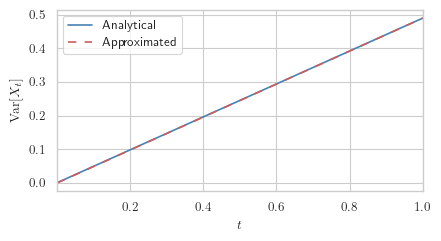

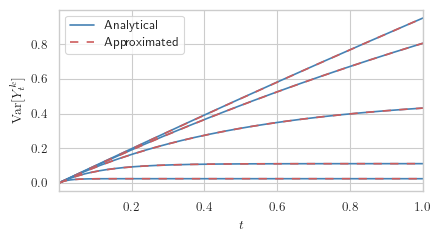

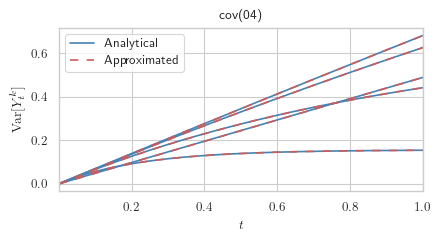

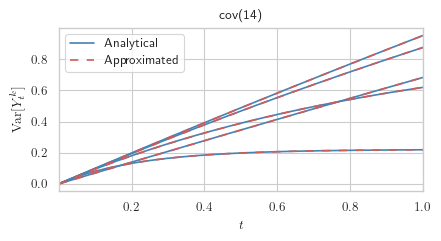

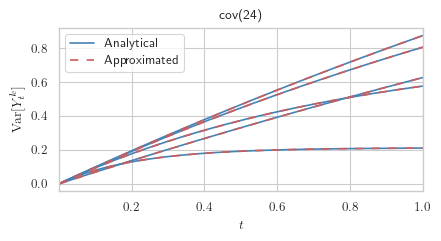

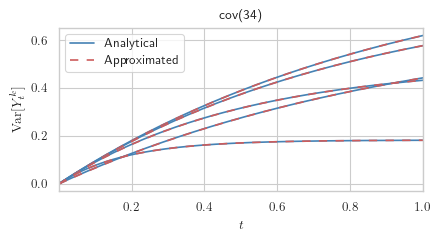

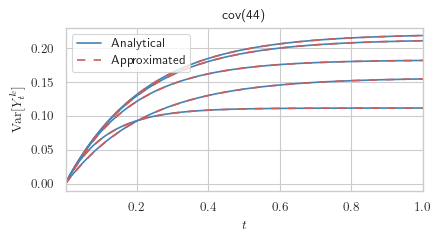

In [12]:
import seaborn as sns
sns.set(font_scale=6., rc={'text.usetex' : True}, style='whitegrid')
sns.set_context('paper')

t = torch.arange(1000+1)/1000
t = t[1:]
sigma_t = covZ(t, t, omega, gamma, g_max)
print('t',t.shape)
print('sigma',sigma_t.shape)
ts = np.linspace(0., 1., 1000)
sigma_t_approx = np.stack([get_result(t,num_k,gamma) for t in ts])
print('sigma_t_approx',sigma_t_approx.shape)

fig, ax = plt.subplots(figsize=(4.5, 2.5), tight_layout=True)
ax.plot(t, sigma_t[:, 0, 0], color='steelblue')
ax.plot(t, sigma_t_approx[:, 0, 0], linestyle=(0, (5, 5)), color='indianred')
ax.legend(['Analytical', 'Approximated'], loc='upper left', )
ax.set_xlabel('$t$')
ax.set_ylabel('$\\mathrm{Var}[X_t]$')
ax.set_xlim(t.min(), t.max())
plt.show()


fig, ax = plt.subplots(figsize=(4.5, 2.5), tight_layout=True)
for k in range(num_k):
    ax.plot(t, sigma_t[:, k+1, k+1], color='steelblue')
    ax.plot(t, sigma_t_approx[:, k+1, k+1], linestyle=(0, (5, 5)), color='indianred')

ax.legend(['Analytical', 'Approximated'], loc='upper left', )
ax.set_xlabel('$t$')
ax.set_ylabel('$\\mathrm{Var}[Y^{k}_t]$')
ax.set_xlim(t.min(), t.max())
plt.show()

for j in range(num_k):
    fig, ax = plt.subplots(figsize=(4.5, 2.5), tight_layout=True)
    plt.title(f'cov({j}{k})')
    for k in range(num_k):
        ax.plot(t, sigma_t[:, j, k], color='steelblue')
        ax.plot(t, sigma_t_approx[:, j, k], linestyle=(0, (5, 5)), color='indianred')

    ax.legend(['Analytical', 'Approximated'], loc='upper left', )
    ax.set_xlabel('$t$')
    ax.set_ylabel('$\\mathrm{Var}[Y^{k}_t]$')
    ax.set_xlim(t.min(), t.max())
    plt.show()

/tmp/ipykernel_23698/569544583.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dt = torch.tensor(T/N)


normalize variance with 1.0
dtype torch.float32
g_max=1.0
F tensor([[  0.0000,  -0.0488,  -0.0355,   0.1577,  -0.1270,   0.1092],
        [  0.0000,  -0.0500,  -0.0000,  -0.0000,  -0.0000,  -0.0000],
        [  0.0000,  -0.0000,  -0.2236,  -0.0000,  -0.0000,  -0.0000],
        [  0.0000,  -0.0000,  -0.0000,  -1.0000,  -0.0000,  -0.0000],
        [  0.0000,  -0.0000,  -0.0000,  -0.0000,  -4.4721,  -0.0000],
        [  0.0000,  -0.0000,  -0.0000,  -0.0000,  -0.0000, -20.0000]])
G tensor([0.9991, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])
t=0.0009990009712055326
S torch.Size([1, 5, 5])
t=0.001998001942411065
S torch.Size([1, 5, 5])
t=0.0029970030300319195
S torch.Size([1, 5, 5])
t=0.00399600388482213
S torch.Size([1, 5, 5])
t=0.004995004739612341
S torch.Size([1, 5, 5])
t=0.005994006060063839
S torch.Size([1, 5, 5])
t=0.00699300691485405
S torch.Size([1, 5, 5])
t=0.00799200776964426
S torch.Size([1, 5, 5])
t=0.008991008624434471
S torch.Size([1, 5, 5])
t=0.009990009479224682
S torch.Size([1

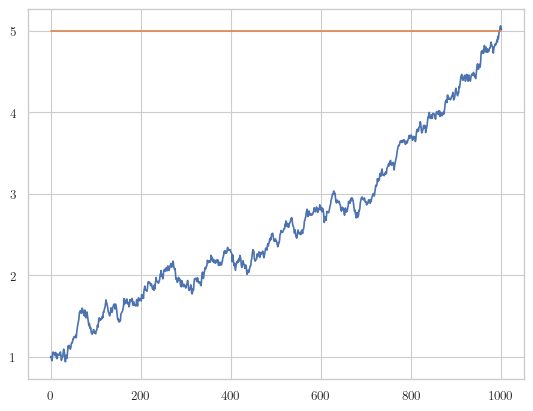

In [13]:
start = 0.0
end = 1.0

T = torch.tensor([1.0]) * end
N = 1000
dt = torch.tensor(T/N)
bs = 1000
K = 5
H = 0.5
gamma_min = None
gamma_max = 20.0

a = 1.0
b = 5.0

x0 = torch.ones(bs,2) * a
xT = torch.ones(bs,2) * b

fbb = FractionalSchrödingerBridge(H=H, K=K, gamma_min=gamma_min,gamma_max=gamma_max)

omega = fbb.omega 
gamma = fbb.gamma

g_max = 1.0

F = torch.zeros(K+1,K+1)
F[:,1:] = -torch.vstack([g_max*(omega * gamma)[0],torch.diag(gamma[0])])
print('F',F)
G = torch.ones(K+1)
G[0] = torch.sum(omega) * g_max
print('G',G)

Z = torch.ones(bs,2,N+1,K+1)
Z[:,:,:,1:] = 0
z0 =  Z[:,:,0,:]
timesteps = torch.linspace(start, end, N+2)


for n in range(N):
    t = timesteps[n+1][None]
    print(f't={t[0]}')
    GG = G[None,None,:,None] * G[None,None,None,:]
    dw = torch.sqrt(dt) * torch.randn_like(z0[:,:,0])[:,:,None]
    x = z0[:,:,0]
    Y = z0[:,:,1:]
    score = score_fn(t,T,x,Y,xT,omega, gamma, g_max)

    # print('T',T.shape)
    # print('t',t.shape)
    # print('F',F[None,None,:,:].shape)
    # print('z0',z0.shape)
    # print('Fz0',matrix_vector_mp(F[None,None,:,:], z0).shape)
    # print('dt',dt.shape)
    # print('GG',GG.shape)
    # print('GGscore',matrix_vector_mp(GG, score).shape)
    # print('dw',dw.shape)
    # print('score',score.shape)
    z1 = z0 + (matrix_vector_mp(F[None,None,:,:], z0) + matrix_vector_mp(GG, score))*dt + G[None,None,:] * dw
    
    Z[:,:,n+1] = z1

    if torch.isnan(Z).any():
        print(f'Found nan in Z at t={t[0,0]}')
        break

    z0 = z1

print(torch.max(Z))
print(torch.min(Z))
plt.plot(Z[0,0,:,0])
plt.plot(torch.ones_like(Z[0,0,:,0])*b)


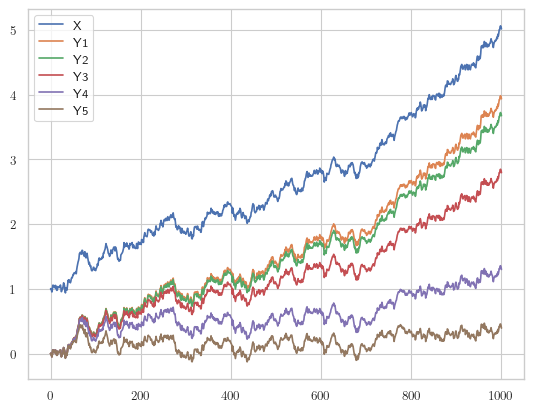

In [14]:
plt.plot(Z[0,0,:,0],label=f'X')
for k in range(K):
    plt.plot(Z[0,0,:,k+1],label=f'Y{k+1}')

plt.legend()

In [20]:
Z = torch.ones(bs,2,N+1,K+1)
Z[:,:,:,1:] = 0
z0 =  Z[:,:,0,:]
timesteps = torch.linspace(start, end, N+2)


for n in range(N):

    t0 = timesteps[n][None] * torch.ones(bs)
    t1 = timesteps[n+1][None] * torch.ones(bs)
    x = z0[:,:,0]
    Y = z0[:,:,1:]
    print('t0',t0.shape)
    mu = meanZ(t0,t1,x,Y,omega,gamma,g_max)
    cov = covZ(t1,t1,omega, gamma, g_max, s=t0, eps=1e-4)
    print('cov',cov.shape)
    dz = mu + sample_from_batch_multivariate_normal(cov,c=x.shape[1],h=1,w=1,batch_size=bs, aug_dim=K+1)[:,:,0,0,:]
    z1 = z0 + dz
    
    Z[:,:,n+1] = z1

    if torch.isnan(Z).any():
        print(f'Found nan in Z at t={t[0,0]}')
        break

    z0 = z1

print(torch.max(Z))
print(torch.min(Z))
plt.plot(Z[0,0,:,0])
plt.plot(torch.ones_like(Z[0,0,:,0])*b)

t0 torch.Size([1000])
mean_x torch.Size([1000, 2, 1])
mean_y torch.Size([1000, 2, 5])
s torch.Size([1000, 1, 1])
t torch.Size([1000, 1, 1])
T torch.Size([1000, 1, 1])
omega torch.Size([1, 5])
gamma torch.Size([1, 5])
Sig[:,0,0] torch.Size([1000])
S torch.Size([1000, 5, 5])
covX torch.Size([1000])
S torch.Size([1000, 5, 5])
cov torch.Size([1000, 6, 6])
t0 torch.Size([1000])
mean_x torch.Size([1000, 2, 1])
mean_y torch.Size([1000, 2, 5])
s torch.Size([1000, 1, 1])
t torch.Size([1000, 1, 1])
T torch.Size([1000, 1, 1])
omega torch.Size([1, 5])
gamma torch.Size([1, 5])
Sig[:,0,0] torch.Size([1000])
S torch.Size([1000, 5, 5])
covX torch.Size([1000])
S torch.Size([1000, 5, 5])
cov torch.Size([1000, 6, 6])


ValueError: Expected parameter covariance_matrix (Tensor of shape (1000, 6, 6)) of distribution MultivariateNormal(loc: torch.Size([1000, 6]), covariance_matrix: torch.Size([1000, 6, 6])) to satisfy the constraint PositiveDefinite(), but found invalid values:
tensor([[[0.0011, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020],
         [0.0020, 0.0011, 0.0010, 0.0010, 0.0010, 0.0010],
         [0.0020, 0.0010, 0.0011, 0.0010, 0.0010, 0.0010],
         [0.0020, 0.0010, 0.0010, 0.0011, 0.0010, 0.0010],
         [0.0020, 0.0010, 0.0010, 0.0010, 0.0011, 0.0010],
         [0.0020, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011]],

        [[0.0011, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020],
         [0.0020, 0.0011, 0.0010, 0.0010, 0.0010, 0.0010],
         [0.0020, 0.0010, 0.0011, 0.0010, 0.0010, 0.0010],
         [0.0020, 0.0010, 0.0010, 0.0011, 0.0010, 0.0010],
         [0.0020, 0.0010, 0.0010, 0.0010, 0.0011, 0.0010],
         [0.0020, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011]],

        [[0.0011, 0.0020, 0.

In [ ]:
from scipy.stats import wasserstein_distance

max_wsd = -float('inf')
min_wsd = float('inf')
mean_wsd = 0.0
for _ in range(N):

    y1 = torch.randn(1000)
    y2 = torch.randn(1000)

    distance = wasserstein_distance(y1,y2)

    if max_wsd<distance:
        max_wsd=distance
    if min_wsd>distance:
        min_wsd=distance

    mean_wsd += distance

mean_wsd = mean_wsd/N

print('max_wsd:',max_wsd)
print('min_wsd:',min_wsd)
print('mean_wsd:',mean_wsd)

max_wsd: 0.16697177673250554
min_wsd: 0.023884189314907413
mean_wsd: 0.05733992185674939


In [ ]:
Z_hat = torch.ones(bs,2,N+1,K+1)
Z_hat[:,:,:,1:] = 0
z0 =  Z[:,:,0,:]
wsd = torch.zeros(N+1,K+1)

timesteps = torch.linspace(start, end, N+2)
for n in range(N):
    t = timesteps[n+1] * torch.ones(bs)
    print(f't={t[0]}')
    print('sample_pinned',sample_pinned(t,T,x0,xT,omega,gamma,g_max).shape)
    Z_hat[:,:,n+1,:] = sample_pinned(t,T,x0,xT,omega,gamma,g_max)
    #wsd[n+1,0] = wasserstein_distance(Z_hat[:,0,n+1,0],Z[:,0,n+1,0])
    for k in range(K+1):
        wsd[n+1,k] = wasserstein_distance(Z_hat[:,0,n+1,k],Z[:,0,n+1,k])
        print(f'distance for k={k} at:', wsd[n+1,k])

print('minimal distance',torch.min(wsd))
print('maximal distance',torch.max(wsd))
print('average distance',torch.mean(wsd))
               
#print('minimal distance',torch.min(wsd[:,0]))
#print('maximal distance',torch.max(wsd[:,0]))
#print('average distance',torch.mean(wsd[:,0]))

t=0.0009990009712055326
S torch.Size([1000, 5, 5])
S torch.Size([1000, 5, 5])
var torch.Size([1000, 1, 1])
mu torch.Size([1000, 2, 6])
Sig_zx torch.Size([1000, 6])
xT torch.Size([1000, 2])
x0 torch.Size([1000, 2])
Sig(xT-x0) torch.Size([1000, 2, 6])
dmu torch.Size([1000, 2, 6])
Sig[:,0,0] torch.Size([1000])
S torch.Size([1000, 5, 5])
covX torch.Size([1000])
S torch.Size([1000, 5, 5])


ValueError: Expected parameter covariance_matrix (Tensor of shape (1000, 6, 6)) of distribution MultivariateNormal(loc: torch.Size([1000, 6]), covariance_matrix: torch.Size([1000, 6, 6])) to satisfy the constraint PositiveDefinite(), but found invalid values:
tensor([[[ 9.9626e-04, -5.0149e+04, -9.4264e+03, -9.6973e+02, -6.7329e+00,
           2.4921e-06],
         [-5.0149e+04, -2.5392e+15, -4.7730e+14, -4.9101e+13, -3.4092e+11,
          -1.3755e+04],
         [-9.4264e+03, -4.7730e+14, -8.9718e+13, -9.2295e+12, -6.4082e+10,
          -2.5856e+03],
         [-9.6973e+02, -4.9101e+13, -9.2295e+12, -9.4947e+11, -6.5923e+09,
          -2.6598e+02],
         [-6.7329e+00, -3.4092e+11, -6.4082e+10, -6.5923e+09, -4.5771e+07,
          -1.8458e+00],
         [ 2.4921e-06, -1.3755e+04, -2.5856e+03, -2.6598e+02, -1.8458e+00,
           1.0753e-03]],

        [[ 9.9626e-04, -5.0149e+04, -9.4264e+03, -9.6973e+02, -6.7329e+00,
           2.4921e-06],
         [-5.0149e+04, -2.5392e+15, -4.7730e+